In [1]:
!git clone https://github.com/Mickrbl/TaxiNY.git
%cd TaxiNY

Cloning into 'TaxiNY'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 80 (delta 1), reused 7 (delta 1), pack-reused 72 (from 1)
Receiving objects: 100% (80/80), 1.01 GiB | 50.11 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Updating files: 100% (45/45), done.
/kaggle/working/TaxiNY


In [2]:
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime
import gc
from sklearn.model_selection import train_test_split

print("Caricamento dataset base e dizionario zone...")
final_dataset = pd.read_parquet('/kaggle/input/datasets/matteopetrelli/final-dataset-ny-taxy/dataset_taxi_completo.parquet')

zones_df = pd.read_csv('/kaggle/working/TaxiNY/data/taxi_zone_lookup.csv')
zones_df = zones_df.rename(columns={'LocationID': 'zone_id'})
zones_df = zones_df[['zone_id', 'Borough', 'Zone']]

print("Ingegnerizzazione delle Feature di Calendario (Modello Stateless per RAG)...")

# 1. AGGIUNGIAMO IL GIORNO DEL MESE (Il mattoncino mancante)
final_dataset['date'] = pd.to_datetime(final_dataset['date'])
final_dataset['day_of_month'] = final_dataset['date'].dt.day

# 2. PULIZIA E CONVERSIONI
# Eliminiamo le zone "fantasma" (Unknown/NV) tenendo solo i quartieri fisici (<= 263)
final_dataset = final_dataset[final_dataset['zone_id'] <= 263]
final_dataset['week_of_year'] = final_dataset['week_of_year'].astype('int32')

# 3. SPLIT GEOGRAFICO E DELLE X/Y
manhattan_data = final_dataset[final_dataset['Borough'] == 'Manhattan']
outer_data = final_dataset[final_dataset['Borough'] != 'Manhattan']

# Rimuoviamo il target e le colonne descrittive per l'addestramento
cols_to_drop = ['predicted_demand', 'predicted_supply', 'date', 'Borough', 'Zone']

# --- SET 1: MANHATTAN ---
X_man = manhattan_data.drop(columns=cols_to_drop)
y_demand_man = manhattan_data['predicted_demand']
y_supply_man = manhattan_data['predicted_supply']

# TORNAMO ALLO SPLIT CASUALE! (Ora il modello impara da tutte le stagioni in modo uniforme)
X_train_man, X_test_man, y_demand_train_man, y_demand_test_man = train_test_split(
    X_man, y_demand_man, test_size=0.2, random_state=42
)
_, _, y_supply_train_man, y_supply_test_man = train_test_split(
    X_man, y_supply_man, test_size=0.2, random_state=42
)

# --- SET 2: OUTER BOROUGHS ---
X_out = outer_data.drop(columns=cols_to_drop)
y_demand_out = outer_data['predicted_demand']
y_supply_out = outer_data['predicted_supply']

X_train_out, X_test_out, y_demand_train_out, y_demand_test_out = train_test_split(
    X_out, y_demand_out, test_size=0.2, random_state=42
)
_, _, y_supply_train_out, y_supply_test_out = train_test_split(
    X_out, y_supply_out, test_size=0.2, random_state=42
)

print(f"Righe Manhattan: {len(manhattan_data):,} | Righe Periferia: {len(outer_data):,}")
print("\nLe tue colonne di input per l'LLM saranno esattamente queste:")
print(list(X_train_man.columns))

Caricamento dataset base e dizionario zone...
Ingegnerizzazione delle Feature di Calendario (Modello Stateless per RAG)...
Righe Manhattan: 1,300,188 | Righe Periferia: 3,162,228

Le tue colonne di input per l'LLM saranno esattamente queste:
['taxi_type', 'zone_id', 'hour', 'month', 'week_of_year', 'day_of_week', 'is_weekend', 'is_holiday', 'day_of_month']


In [3]:
from sklearn.model_selection import KFold, GridSearchCV
import xgboost as xgb

print("=== INIZIO DOUBLE TUNING SUI CAMPIONI (5%) ===")

# 1. Estraiamo il 5% dei dati per ENTRAMBI i distretti
X_sample_man = X_train_man.sample(frac=0.05, random_state=42)
y_sample_demand_man = y_demand_train_man.loc[X_sample_man.index]

X_sample_out = X_train_out.sample(frac=0.05, random_state=42)
y_sample_demand_out = y_demand_train_out.loc[X_sample_out.index]

print(f"Campione Manhattan: {len(X_sample_man):,} righe")
print(f"Campione Periferia: {len(X_sample_out):,} righe")

# 2. Definiamo la griglia (usiamo la stessa per fare un confronto equo)
param_grid_sample = {
    'max_depth': [12, 14],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [800, 1000]
}

# 3. KFold leggero (3 split)
kf_sample = KFold(n_splits=3, shuffle=True, random_state=42)

# Modello base XGBoost per i test
xgb_base_sample = xgb.XGBRegressor(
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',
    device='cuda',
    random_state=42
)

# ==========================================
# 4. TUNING MANHATTAN
# ==========================================
print("\nAvvio Grid Search per MANHATTAN...")
grid_man = GridSearchCV(
    estimator=xgb_base_sample,
    param_grid=param_grid_sample,
    cv=kf_sample, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_man.fit(X_sample_man, y_sample_demand_man)
best_params_man = grid_man.best_params_
print(f"✅ Migliori parametri Manhattan trovati: {best_params_man}")

# ==========================================
# 5. TUNING OUTER BOROUGHS
# ==========================================
print("\nAvvio Grid Search per OUTER BOROUGHS...")
grid_out = GridSearchCV(
    estimator=xgb_base_sample,
    param_grid=param_grid_sample,
    cv=kf_sample, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_out.fit(X_sample_out, y_sample_demand_out)
best_params_out = grid_out.best_params_
print(f"✅ Migliori parametri Periferia trovati: {best_params_out}")

=== INIZIO DOUBLE TUNING SUI CAMPIONI (5%) ===
Campione Manhattan: 52,008 righe
Campione Periferia: 126,489 righe

Avvio Grid Search per MANHATTAN...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:16:25] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:16:25] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic

✅ Migliori parametri Manhattan trovati: {'learning_rate': 0.01, 'max_depth': 12, 'n_estimators': 1000}

Avvio Grid Search per OUTER BOROUGHS...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:29:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:29:42] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic

✅ Migliori parametri Periferia trovati: {'learning_rate': 0.05, 'max_depth': 12, 'n_estimators': 800}


Generazione grafici risultati Double Grid Search...


/tmp/ipykernel_24/1887936985.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_24/1887936985.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_24/1887936985.py:55: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24/1887936985.py:55: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

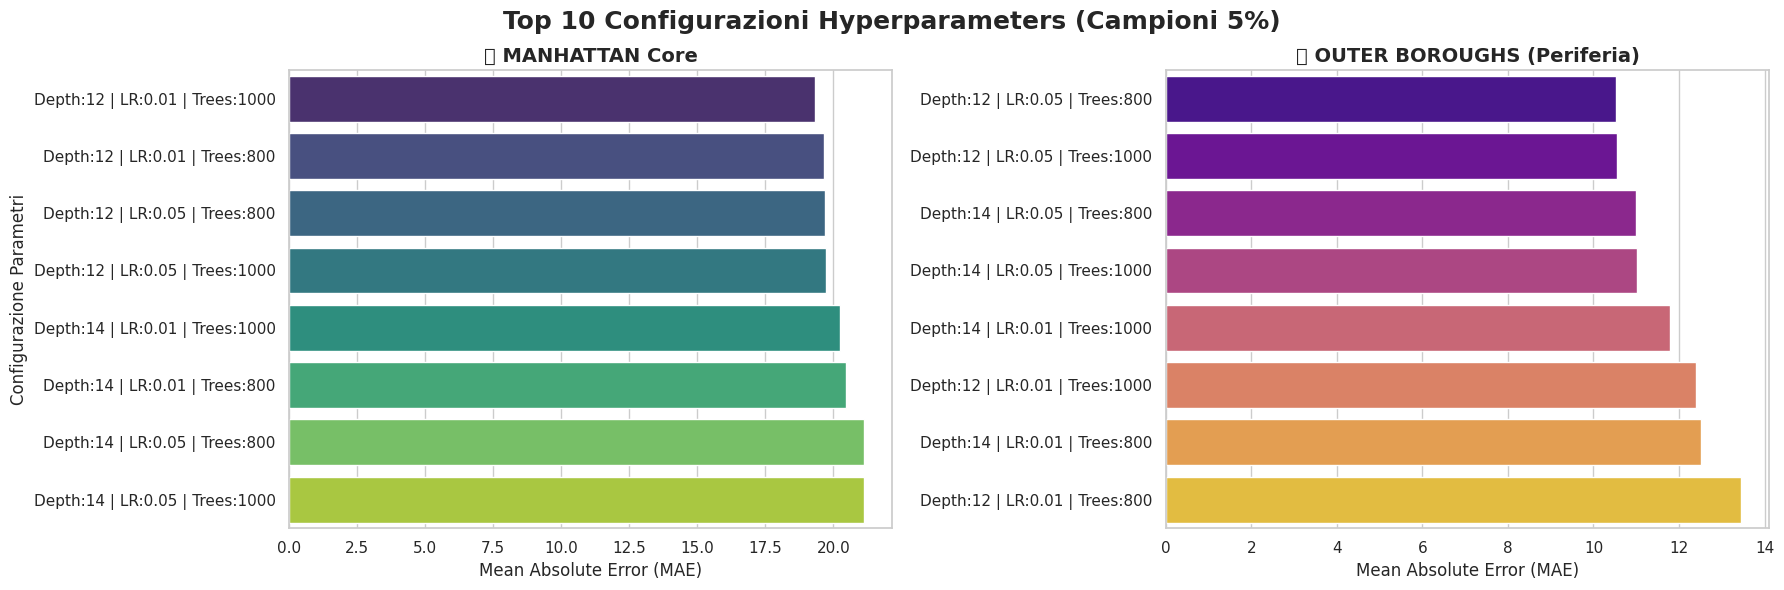

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile
sns.set_theme(style="whitegrid")

print("Generazione grafici risultati Double Grid Search...")

# 1. Funzione rapida per estrarre e pulire i dati di una Grid Search
def prepara_dati_grid(grid_object):
    cv_results = pd.DataFrame(grid_object.cv_results_)
    # Convertiamo il "negative MAE" in positivo
    cv_results['MAE_score'] = -cv_results['mean_test_score']
    # Prendiamo le 10 migliori
    top_10 = cv_results.sort_values(by='MAE_score').head(10).copy()
    # Creiamo la stringa leggibile
    top_10['params_str'] = top_10['params'].apply(
        lambda x: f"Depth:{x['max_depth']} | LR:{x['learning_rate']} | Trees:{x['n_estimators']}"
    )
    return top_10

# 2. Prepariamo i dati per entrambi i distretti
top_10_man = prepara_dati_grid(grid_man)
top_10_out = prepara_dati_grid(grid_out)

# 3. Creiamo la figura con 2 grafici affiancati (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Top 10 Configurazioni Hyperparameters (Campioni 5%)", fontsize=18, fontweight='bold')

# --- Grafico Sinistro: MANHATTAN ---
sns.barplot(
    data=top_10_man, 
    x='MAE_score', 
    y='params_str', 
    palette='viridis', 
    ax=axes[0]
)
axes[0].set_title("👑 MANHATTAN Core", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Mean Absolute Error (MAE)", fontsize=12)
axes[0].set_ylabel("Configurazione Parametri", fontsize=12)

# --- Grafico Destro: OUTER BOROUGHS ---
sns.barplot(
    data=top_10_out, 
    x='MAE_score', 
    y='params_str', 
    palette='plasma', # Usiamo un colore diverso per distinguerli
    ax=axes[1]
)
axes[1].set_title("🏙️ OUTER BOROUGHS (Periferia)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Mean Absolute Error (MAE)", fontsize=12)
axes[1].set_ylabel("") # Togliamo l'etichetta Y per tenere il grafico pulito

plt.tight_layout()
plt.subplots_adjust(top=0.88) # Lasciamo un po' di spazio per il titolo globale
plt.show()

In [5]:
import xgboost as xgb
import gc


# Puliamo la memoria dai DataFrame che non ci servono più (FONDAMENTALE)
try:
    del df, demand_df, supply_df, manhattan_data, outer_data
except NameError:
    pass # Ignora l'errore se li abbiamo già cancellati
gc.collect()

print("Inizializzazione dei modelli con i doppi parametri ottimali...")

# Modello ottimizzato su misura per MANHATTAN
xgb_ottimizzato_man = xgb.XGBRegressor(
    **best_params_man,           # <-- Usa le risposte del tuning di Manhattan
    subsample=0.8,               
    colsample_bytree=0.8,
    enable_categorical=True,     
    tree_method='hist',
    device='cuda',               
    random_state=42
)

# Modello ottimizzato su misura per PERIFERIA
xgb_ottimizzato_out = xgb.XGBRegressor(
    **best_params_out,           # <-- Usa le risposte del tuning degli Outer Boroughs
    subsample=0.8,               
    colsample_bytree=0.8,
    enable_categorical=True,     
    tree_method='hist',
    device='cuda',               
    random_state=42
)

# ==========================================
# ADDESTRAMENTO COMPLETO SUL 100% DEI DATI
# ==========================================


print("\n🚀 Addestramento MANHATTAN (Domanda)...")
#model_demand_manhattan = xgb_ottimizzato_man.fit(X_train_man, y_demand_train_man)
model_demand_manhattan = xgb_ottimizzato_man.fit(X_train_man, np.log1p(y_demand_train_man))

print("🚀 Addestramento OUTER BOROUGHS (Domanda)...")
#model_demand_outer = xgb_ottimizzato_out.fit(X_train_out, y_demand_train_out)
model_demand_outer = xgb_ottimizzato_out.fit(X_train_out, np.log1p(y_demand_train_out))

print("🚀 Addestramento MANHATTAN (Offerta)...")
#model_supply_manhattan = xgb_ottimizzato_man.fit(X_train_man, y_supply_train_man)
#model_supply_manhattan = xgb_ottimizzato_man.fit(X_train_man, np.log1p(y_demand_train_man))

print("🚀 Addestramento OUTER BOROUGHS (Offerta)...")
#model_supply_outer = xgb_ottimizzato_out.fit(X_train_out, y_supply_train_out)
#model_supply_outer = xgb_ottimizzato_out.fit(X_train_out, np.log1p(y_demand_train_out))

print("\n✅ Tutti i 4 modelli IA sono stati addestrati con i loro parametri specifici!")

Inizializzazione dei modelli con i doppi parametri ottimali...

🚀 Addestramento MANHATTAN (Domanda)...
🚀 Addestramento OUTER BOROUGHS (Domanda)...
🚀 Addestramento MANHATTAN (Offerta)...
🚀 Addestramento OUTER BOROUGHS (Offerta)...

✅ Tutti i 4 modelli IA sono stati addestrati con i loro parametri specifici!


In [6]:
import joblib
import os

OUTPUT_DIR = '/kaggle/working/modelli_salvati'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("💾 Salvataggio dei modelli su disco in corso...")

joblib.dump(model_demand_manhattan, os.path.join(OUTPUT_DIR, 'xgb_demand_manhattan.joblib'))
#joblib.dump(model_supply_manhattan, os.path.join(OUTPUT_DIR, 'xgb_supply_manhattan.joblib'))
joblib.dump(model_demand_outer, os.path.join(OUTPUT_DIR, 'xgb_demand_outer.joblib'))
#joblib.dump(model_supply_outer, os.path.join(OUTPUT_DIR, 'xgb_supply_outer.joblib'))

print(f"🎉 Finito! Trovi i 4 file .pkl nella cartella {OUTPUT_DIR} pronti per il download dal pannello laterale.")

💾 Salvataggio dei modelli su disco in corso...
🎉 Finito! Trovi i 4 file .pkl nella cartella /kaggle/working/modelli_salvati pronti per il download dal pannello laterale.



🔄 Avvio Valutazione per: DOMANDA - Manhattan Core


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:42:56] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


📊 MAE Finale sul Test Set: 12.67 (Scarto medio per ora/zona)


/tmp/ipykernel_24/2899112229.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_by_hour, x='hour', y='Abs_Error', ax=axes[1, 1], palette='magma')


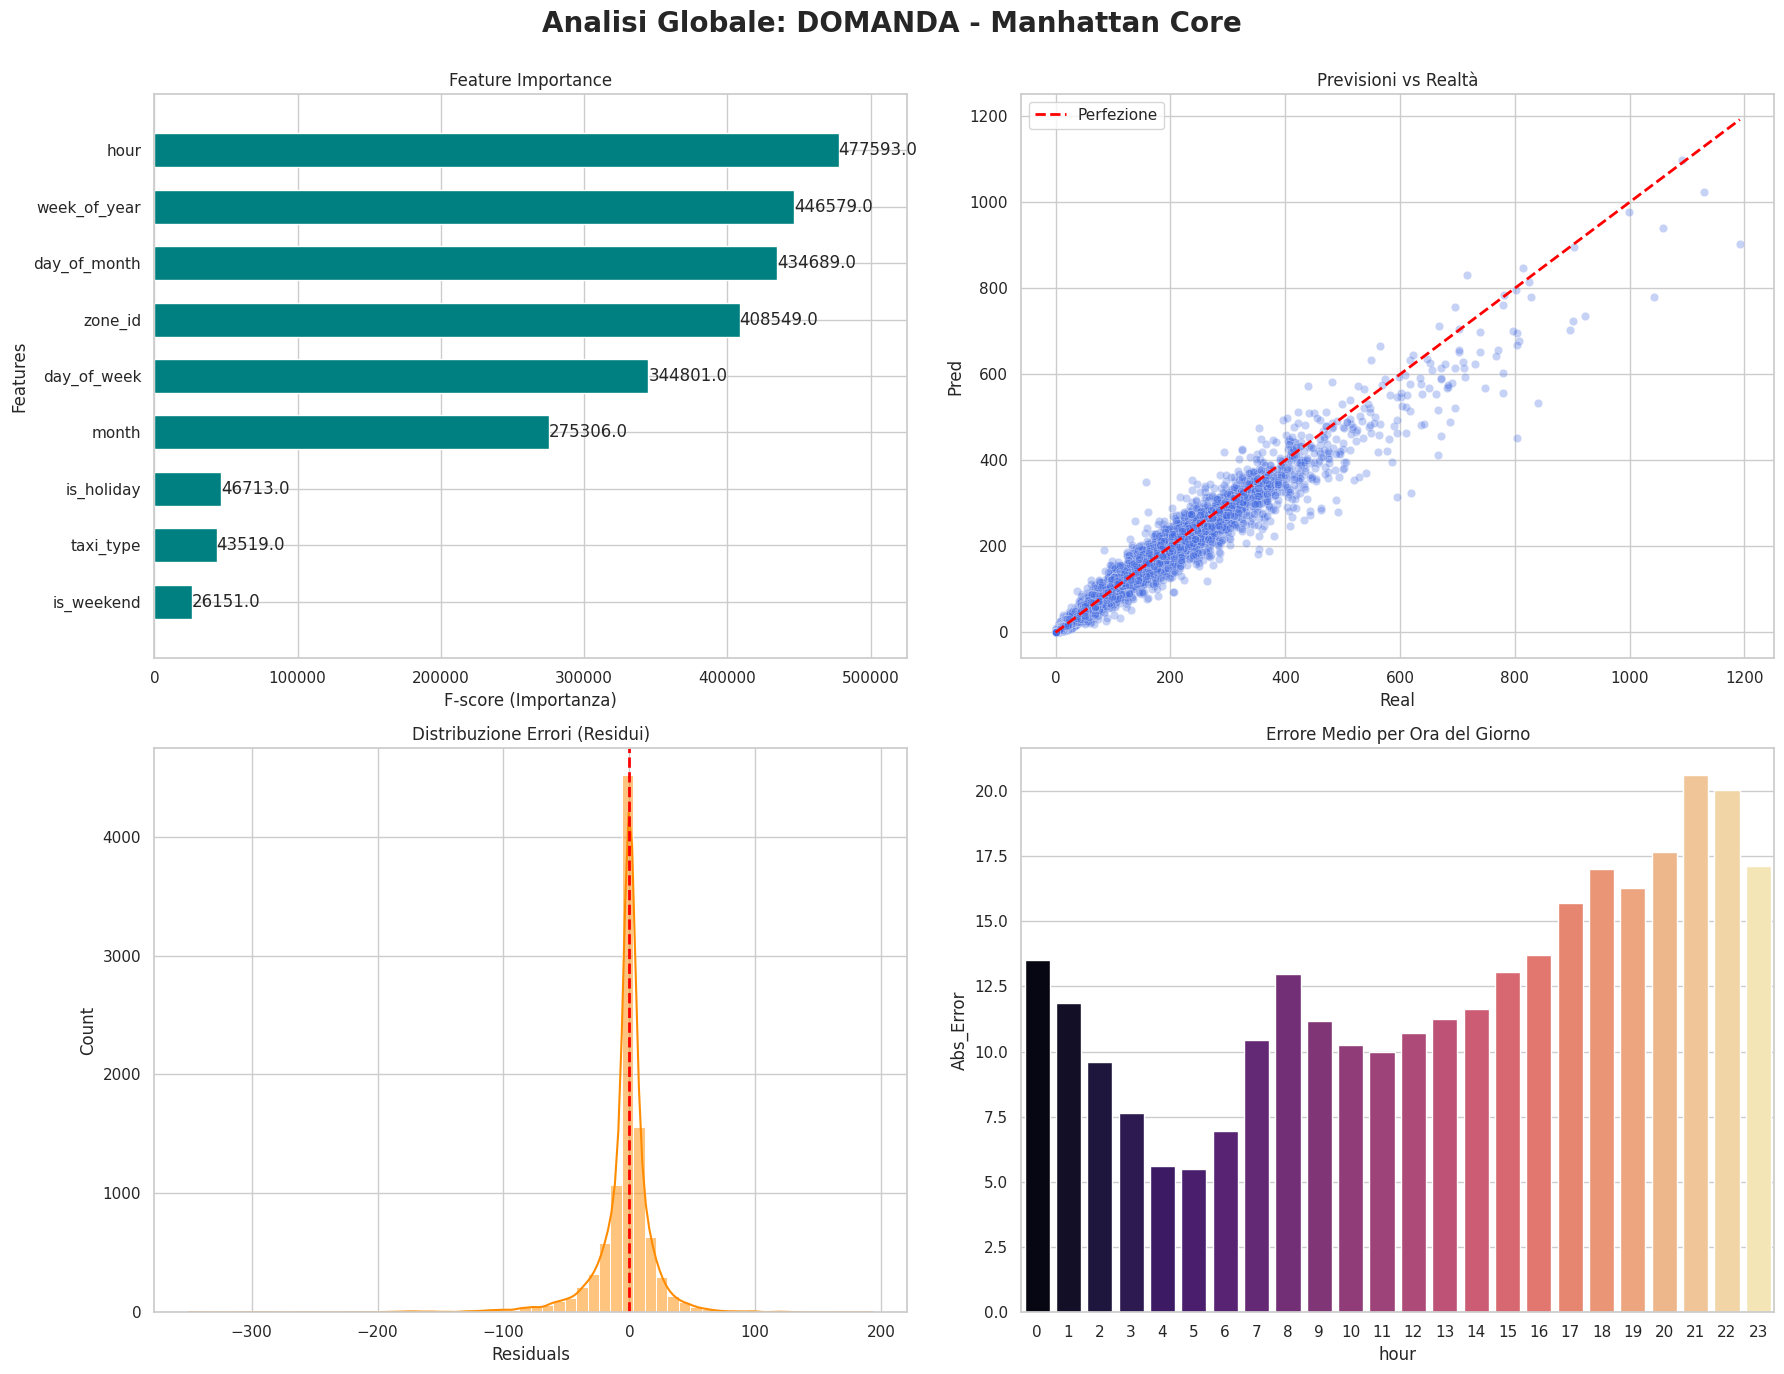

/tmp/ipykernel_24/2899112229.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15_zones, x='Abs_Error', y='Zone', palette='Reds_r')


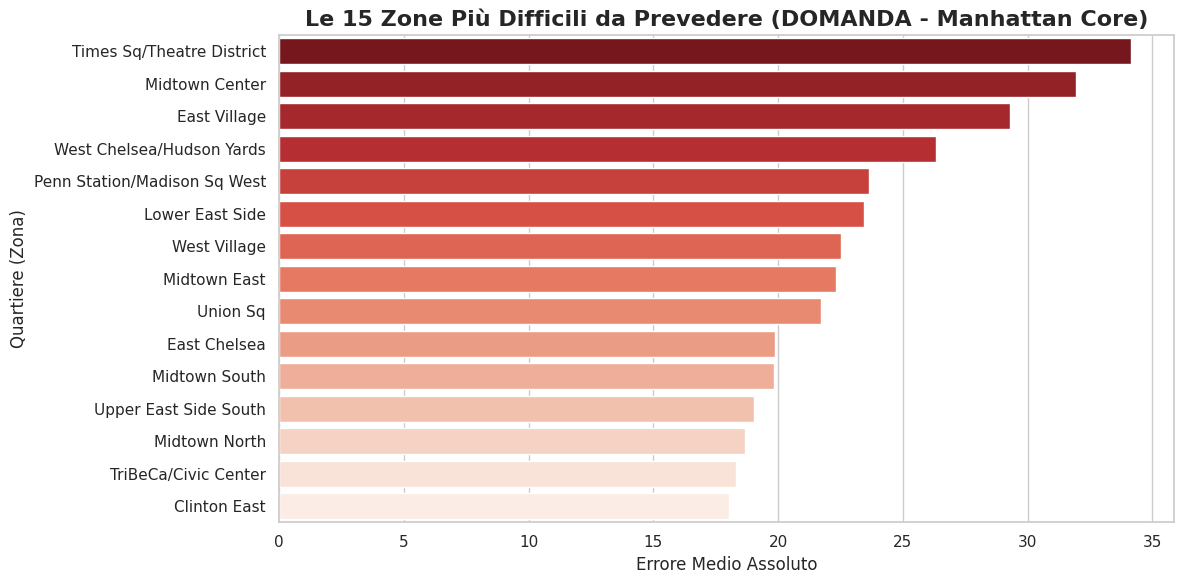


🔄 Avvio Valutazione per: DOMANDA - Outer Boroughs (Queens, Brooklyn, Bronx, Staten Island)
📊 MAE Finale sul Test Set: 5.96 (Scarto medio per ora/zona)


/tmp/ipykernel_24/2899112229.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_by_hour, x='hour', y='Abs_Error', ax=axes[1, 1], palette='magma')


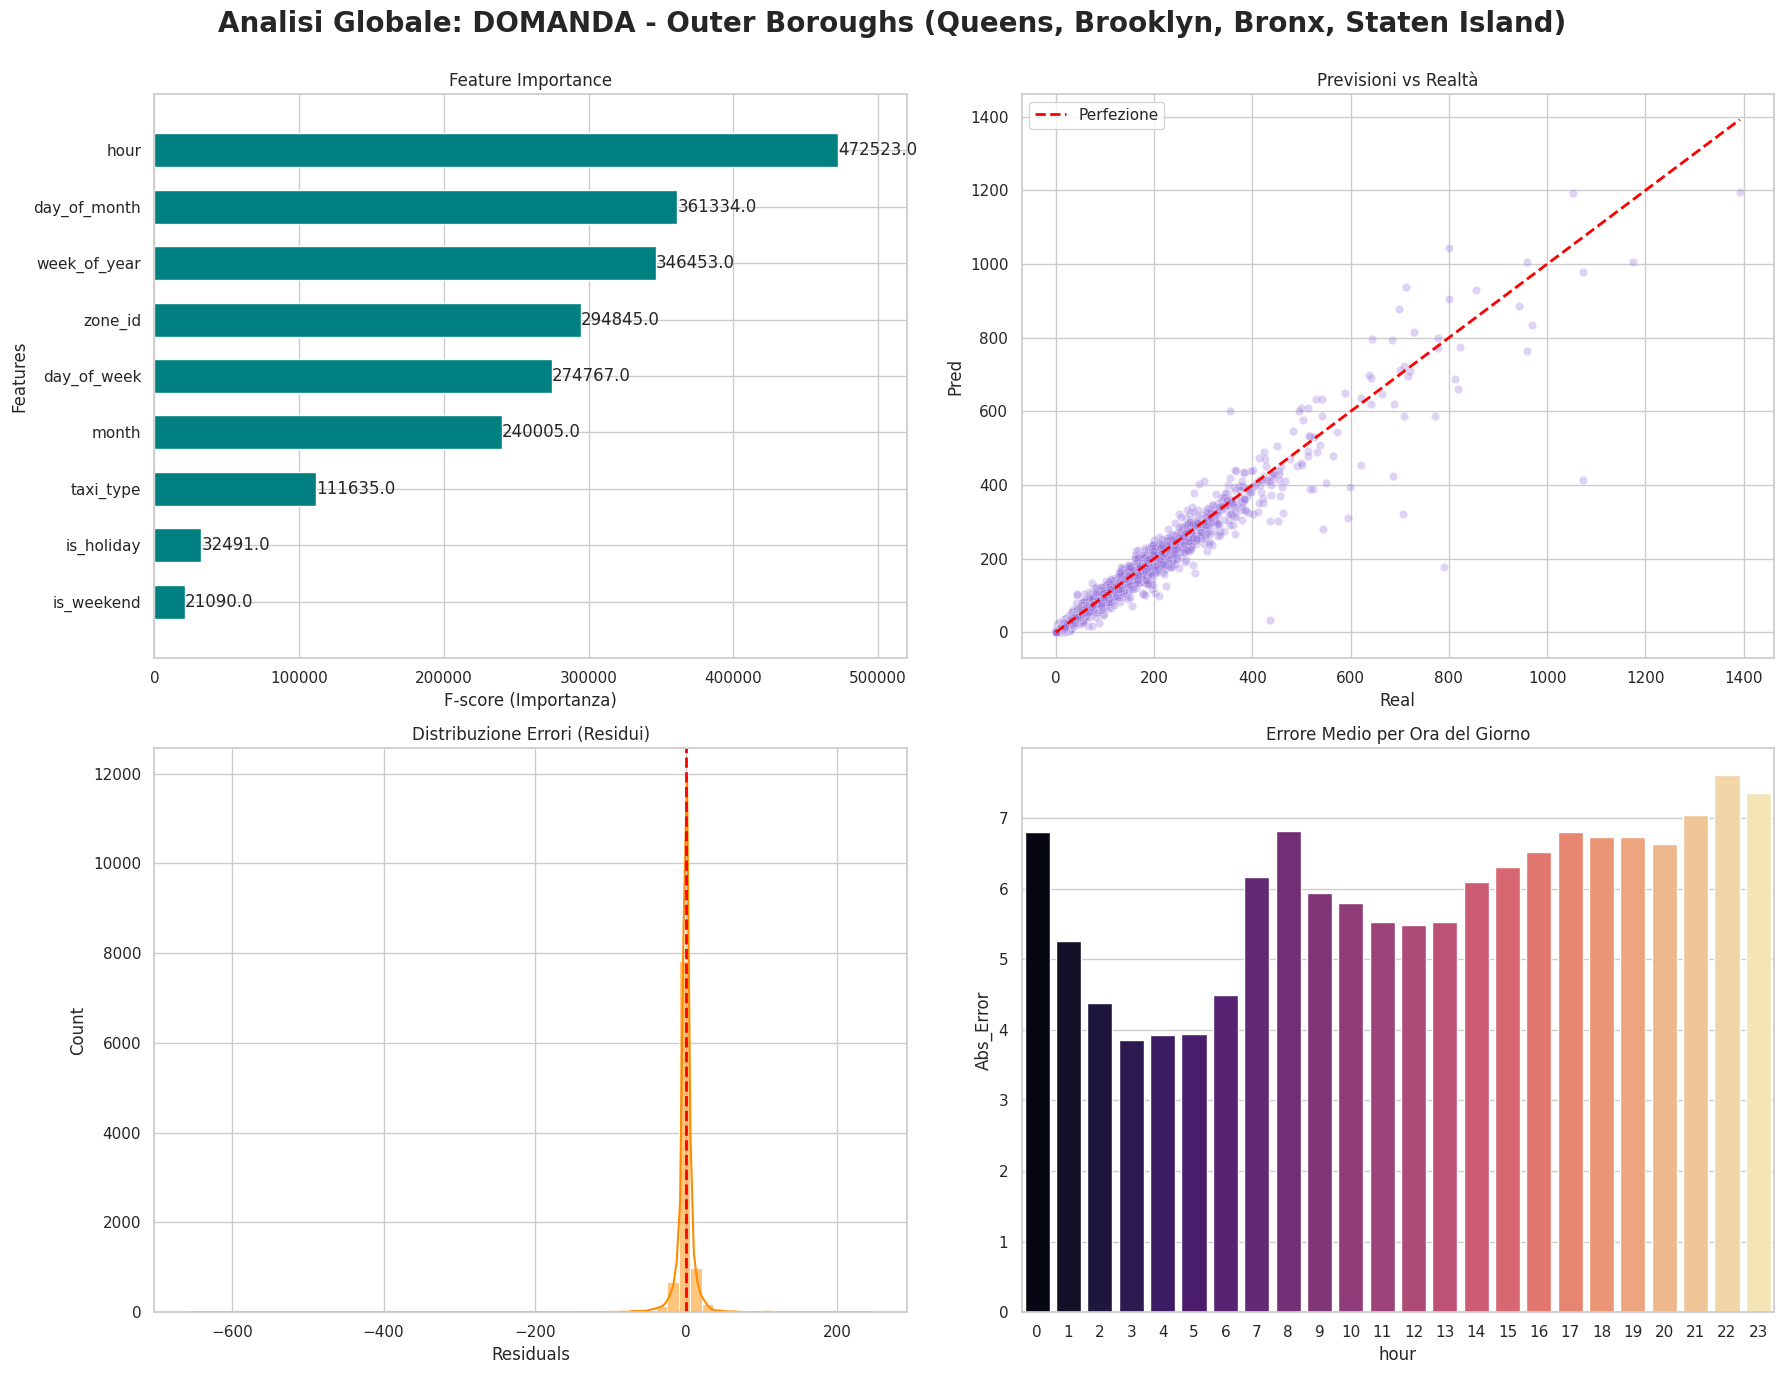

/tmp/ipykernel_24/2899112229.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15_zones, x='Abs_Error', y='Zone', palette='Reds_r')


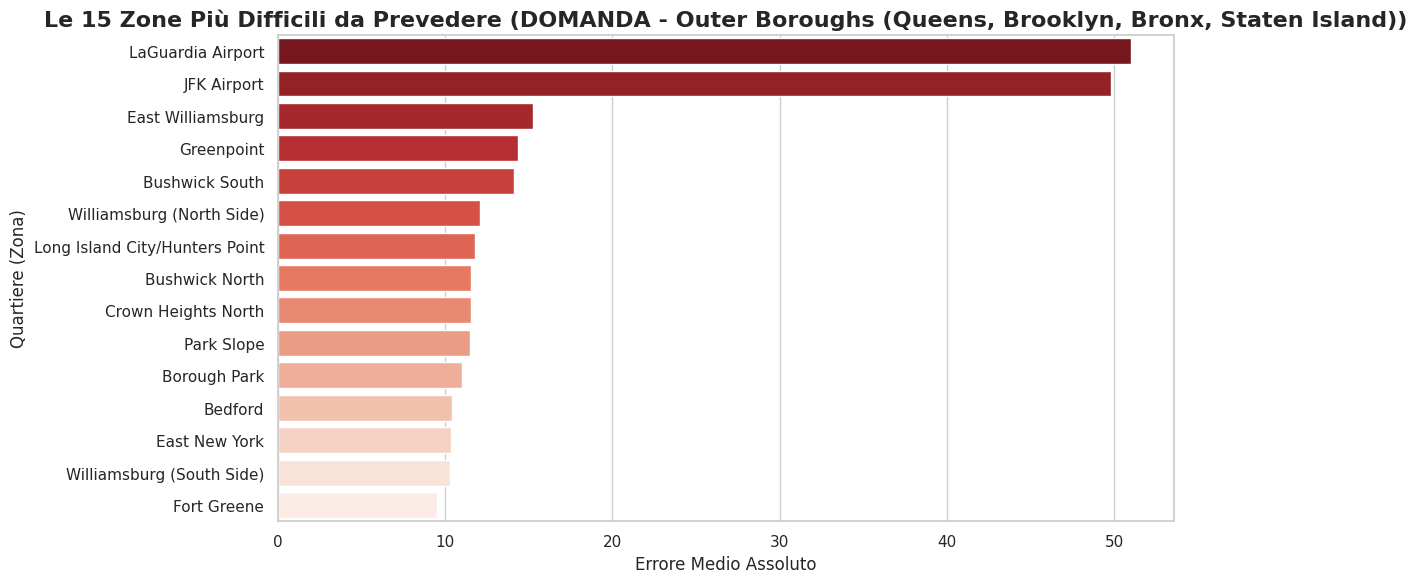

'\n# 3. Analizziamo l\'Offerta di Manhattan (Taxi disponibili)\ncrea_dashboard_valutazione(\n    model=model_supply_manhattan, \n    X_test=X_test_man, \n    y_test=y_supply_test_man,\n    titolo_modello="OFFERTA - Manhattan Core",\n    colore_tema=\'mediumseagreen\', \n    usa_logaritmo= False\n)\n\n\n\n# 4. Analizziamo l\'Offerta in Periferia\ncrea_dashboard_valutazione(\n    model=model_supply_outer, \n    X_test=X_test_out, \n    y_test=y_supply_test_out, \n    titolo_modello="OFFERTA - Outer Boroughs",\n    colore_tema=\'goldenrod\',\n    usa_logaritmo= False\n)'

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

# Impostiamo lo stile globale
sns.set_theme(style="whitegrid")

def crea_dashboard_valutazione(model, X_test, y_test, titolo_modello, colore_tema='royalblue', usa_logaritmo=False):
    """
    Funzione universale che calcola le predizioni, il MAE e genera 
    sia la Dashboard a 4 quadranti che la classifica delle Top 15 Zone critiche.
    """
    print(f"\n" + "="*50)
    print(f"🔄 Avvio Valutazione per: {titolo_modello}")
    print("="*50)

    # 1. Calcoliamo le predizioni
    
    
    # Se hai applicato il trucco del logaritmo in fase di addestramento:
    if usa_logaritmo:
        log_preds = model.predict(X_test)
        preds = np.expm1(log_preds)
    else: 
        preds = model.predict(X_test)
        
    preds = [max(0.0, p) for p in preds] # Niente corse negative
    
    # 1. Predizioni
    #preds = model.predict(X_test)
    #preds = [max(0.0, p) for p in preds] # Evitiamo numeri negativi
    
    # 2. Calcolo Errore
    mae_final = mean_absolute_error(y_test, preds)
    print(f"📊 MAE Finale sul Test Set: {mae_final:.2f} (Scarto medio per ora/zona)")
    
    # 3. Preparazione Dati
    eval_df = X_test.copy()
    eval_df['Real'] = y_test
    eval_df['Pred'] = preds
    eval_df['Abs_Error'] = abs(eval_df['Real'] - eval_df['Pred'])
    eval_df['Residuals'] = eval_df['Pred'] - eval_df['Real']
    
    # Uniamo i nomi delle zone se zones_df è disponibile in memoria
    try:
        eval_df = eval_df.merge(zones_df, on='zone_id', how='left')
    except NameError:
        print("⚠️ zones_df non trovato. Le zone appariranno come ID numerici.")
        eval_df['Zone'] = eval_df['zone_id'].astype(str)

    # ==========================================
    # GRAFICI: DASHBOARD A 4 QUADRANTI
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle(f"Analisi Globale: {titolo_modello}", fontsize=20, fontweight='bold')

    # Feature Importance
    xgb.plot_importance(model, ax=axes[0, 0], max_num_features=10, height=0.6, color='teal', title="Feature Importance")
    axes[0, 0].set_xlabel("F-score (Importanza)")
    
    # Scatterplot Reale vs Predetto
    sample_df = eval_df.sample(min(10000, len(eval_df)), random_state=42)
    sns.scatterplot(data=sample_df, x='Real', y='Pred', ax=axes[0, 1], alpha=0.3, color=colore_tema)
    max_val = max(sample_df['Real'].max(), sample_df['Pred'].max())
    axes[0, 1].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfezione')
    axes[0, 1].set_title("Previsioni vs Realtà")
    axes[0, 1].legend()

    # Distribuzione Residui
    sns.histplot(sample_df['Residuals'], bins=60, kde=True, ax=axes[1, 0], color='darkorange')
    axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_title("Distribuzione Errori (Residui)")

    # Errore Medio per Ora
    error_by_hour = eval_df.groupby('hour')['Abs_Error'].mean().reset_index()
    sns.barplot(data=error_by_hour, x='hour', y='Abs_Error', ax=axes[1, 1], palette='magma')
    axes[1, 1].set_title("Errore Medio per Ora del Giorno")

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

    # ==========================================
    # GRAFICO: LE 15 ZONE PIÙ CRITICHE
    # ==========================================
    error_by_zone = eval_df.groupby('Zone')['Abs_Error'].mean().reset_index()
    top_15_zones = error_by_zone.sort_values(by='Abs_Error', ascending=False).head(15)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_15_zones, x='Abs_Error', y='Zone', palette='Reds_r')
    plt.title(f"Le 15 Zone Più Difficili da Prevedere ({titolo_modello})", fontsize=16, fontweight='bold')
    plt.xlabel("Errore Medio Assoluto")
    plt.ylabel("Quartiere (Zona)")
    plt.tight_layout()
    plt.show()

# =========================================================
# ESECUZIONE DELLA FUNZIONE SUI 4 MODELLI FINALI
# =========================================================

# 1. Analizziamo la Domanda di Manhattan
crea_dashboard_valutazione(
    model=model_demand_manhattan, 
    X_test=X_test_man, 
    y_test=y_demand_test_man,
    titolo_modello="DOMANDA - Manhattan Core",
    colore_tema='royalblue',
    usa_logaritmo= True
)

# 2. Analizziamo la Domanda in Periferia (Outer Boroughs)
crea_dashboard_valutazione(
    model=model_demand_outer, 
    X_test=X_test_out, 
    y_test=y_demand_test_out, 
    titolo_modello="DOMANDA - Outer Boroughs (Queens, Brooklyn, Bronx, Staten Island)",
    colore_tema='mediumpurple',
    usa_logaritmo= True
)
'''
# 3. Analizziamo l'Offerta di Manhattan (Taxi disponibili)
crea_dashboard_valutazione(
    model=model_supply_manhattan, 
    X_test=X_test_man, 
    y_test=y_supply_test_man,
    titolo_modello="OFFERTA - Manhattan Core",
    colore_tema='mediumseagreen', 
    usa_logaritmo= False
)



# 4. Analizziamo l'Offerta in Periferia
crea_dashboard_valutazione(
    model=model_supply_outer, 
    X_test=X_test_out, 
    y_test=y_supply_test_out, 
    titolo_modello="OFFERTA - Outer Boroughs",
    colore_tema='goldenrod',
    usa_logaritmo= False
)'''

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

def analizza_errore_flotte(model, X_test, y_test, titolo_modello, usa_logaritmo=False):
    print(f"\n" + "="*55)
    print(f"📊 PRESTAZIONI PER TIPOLOGIA: {titolo_modello}")
    print("="*55)
    
    # 1. Calcoliamo le predizioni
    if usa_logaritmo:
        log_preds = model.predict(X_test)
        preds = np.expm1(log_preds)
    else: 
        preds = model.predict(X_test)
        
    preds = [max(0.0, p) for p in preds] # Niente corse negative
    
    # 2. Creiamo un DataFrame rapido per unire vere y, predizioni e tipi di taxi
    df_analisi = pd.DataFrame({
        'taxi_type': X_test['taxi_type'],
        'Real': y_test,
        'Pred': preds
    })
    
    # 3. Raggruppiamo per tipo di taxi (observed=True perché è una categoria)
    gruppi = df_analisi.groupby('taxi_type', observed=True)
    
    for taxi, data in gruppi:
        if len(data) == 0:
            continue
            
        mae = mean_absolute_error(data['Real'], data['Pred'])
        media_reale = data['Real'].mean()
        
        # Calcoliamo l'errore percentuale (se la media è 0, evitiamo divisioni per zero)
        errore_perc = (mae / media_reale * 100) if media_reale > 0 else 0
        
        print(f"🚕 Flotta: {taxi.upper()}")
        print(f"   ↳ Volume Medio Reale: {media_reale:.1f} corse/ora")
        print(f"   ↳ Errore MAE:         {mae:.1f} corse/ora")
        print(f"   ↳ Errore Relativo:    {errore_perc:.1f}%\n")

# =========================================================
# ESECUZIONE DELLA FUNZIONE SUI 4 MODELLI
# =========================================================

# NOTA: Imposta usa_logaritmo=True solo sui modelli in cui hai usato np.log1p() nel .fit()
# Nel messaggio precedente ti avevo suggerito di usarlo solo per la DOMANDA.

analizza_errore_flotte(model_demand_manhattan, X_test_man, y_demand_test_man, 
                       "DOMANDA - Manhattan", usa_logaritmo=True)

#analizza_errore_flotte(model_supply_manhattan, X_test_man, y_supply_test_man, 
#                       "OFFERTA - Manhattan", usa_logaritmo=False)

analizza_errore_flotte(model_demand_outer, X_test_out, y_demand_test_out, 
                       "DOMANDA - Periferia", usa_logaritmo=True)

#analizza_errore_flotte(model_supply_outer, X_test_out, y_supply_test_out, 
#                       "OFFERTA - Periferia", usa_logaritmo=False)


📊 PRESTAZIONI PER TIPOLOGIA: DOMANDA - Manhattan
🚕 Flotta: GREEN
   ↳ Volume Medio Reale: 2.1 corse/ora
   ↳ Errore MAE:         0.7 corse/ora
   ↳ Errore Relativo:    32.2%

🚕 Flotta: HVFHV
   ↳ Volume Medio Reale: 156.2 corse/ora
   ↳ Errore MAE:         17.6 corse/ora
   ↳ Errore Relativo:    11.3%

🚕 Flotta: YELLOW
   ↳ Volume Medio Reale: 74.0 corse/ora
   ↳ Errore MAE:         11.2 corse/ora
   ↳ Errore Relativo:    15.2%


📊 PRESTAZIONI PER TIPOLOGIA: DOMANDA - Periferia
🚕 Flotta: GREEN
   ↳ Volume Medio Reale: 1.0 corse/ora
   ↳ Errore MAE:         0.6 corse/ora
   ↳ Errore Relativo:    62.5%

🚕 Flotta: HVFHV
   ↳ Volume Medio Reale: 92.4 corse/ora
   ↳ Errore MAE:         10.0 corse/ora
   ↳ Errore Relativo:    10.8%

🚕 Flotta: YELLOW
   ↳ Volume Medio Reale: 5.4 corse/ora
   ↳ Errore MAE:         1.7 corse/ora
   ↳ Errore Relativo:    32.1%



In [9]:
print("=== VOLUMI MEDI REALI (Test Set) ===")

media_domanda_man = y_demand_test_man.mean()
#media_offerta_man = y_supply_test_man.mean()

media_domanda_out = y_demand_test_out.mean()
#media_offerta_out = y_supply_test_out.mean()

print("🗽 MANHATTAN:")
print(f" - Media Domanda Reale: {media_domanda_man:.2f} corse per ora/zona")
#print(f" - Media Offerta Reale: {media_offerta_man:.2f} taxi per ora/zona")

print("\n🏙️ OUTER BOROUGHS (Periferia):")
print(f" - Media Domanda Reale: {media_domanda_out:.2f} corse per ora/zona")
#print(f" - Media Offerta Reale: {media_offerta_out:.2f} taxi per ora/zona")

=== VOLUMI MEDI REALI (Test Set) ===
🗽 MANHATTAN:
 - Media Domanda Reale: 101.15 corse per ora/zona

🏙️ OUTER BOROUGHS (Periferia):
 - Media Domanda Reale: 50.74 corse per ora/zona
